# Lab 13 · pgvector indexes, SQL, and query plans
## Goal
Write vector SQL, build HNSW and IVFFlat indexes, inspect plans, and compare approximate neighbors with an exact baseline. Prerequisite: Lab 12 and SQL SELECT/WHERE/ORDER BY. Planned 120 minutes: 20 SQL, 40 index work, 35 measurements, 25 failure tests/report.

The index experiment uses generated vectors to isolate database behavior. Its neighbor recall is not semantic relevance. PostgreSQL may reasonably choose a sequential scan on a tiny corpus; verify plans rather than assume the index was used.

## Setup
Complete the track README preflight first: install this track's pinned environment and editable package; start PostgreSQL/pgvector with Docker Compose; download the two pinned model snapshots; seed the invented course corpus. Select that Python environment as the kernel. These notebooks need the **whole `labs/rag` folder**, not a standalone upload. They use a real database and local neural models. Missing services or models are errors, not silently replaced by mocks.

Run worked cells first, then implement TODOs, set `RUN_EXERCISES=True`, restart, and run all. Instructor copies enable those checks. `RUN_GENERATION` stays false unless you deliberately enable the separately documented Gemini request. Offline here means no inference API calls after package/model downloads; PostgreSQL is still a real local service. All data are invented and English-language. Never use this teaching database or its public example keys for real student records.

In [1]:
import json
from pathlib import Path
from importlib.metadata import version
import numpy as np
from raglab.config import ROOT, DIMENSION
from raglab import db, models
from raglab.ingestion import corpus, chunk_documents, make_pipeline
RUN_EXERCISES = False
RUN_GENERATION = False
print({p:version(p) for p in ("llama-index-core","pgvector","psycopg","fastapi","sentence-transformers")})
with db.connect() as conn:
    print(conn.execute("SELECT extversion FROM pg_extension WHERE extname='vector'").fetchone())

{'llama-index-core': '0.14.25', 'pgvector': '0.5.0', 'psycopg': '3.3.6', 'fastapi': '0.142.4', 'sentence-transformers': '6.1.0'}
{'extversion': '0.8.1'}


## Steps
### 1. Execute a tenant-filtered cosine query
`<=>` is cosine distance; smaller values rank earlier. A distance operator and index operator class must match. Values are bound as parameters; table/index names must be trusted identifiers, not user text interpolated into SQL.

In [2]:
query="How long can I borrow a camera?"
qv=models.embed([query])[0]
with db.connect() as conn:
    rows=conn.execute("""SELECT doc_id,text,embedding <=> %s AS distance
      FROM rag_course.chunks WHERE tenant=%s
      ORDER BY embedding <=> %s LIMIT %s""",(qv,"alpha",qv,3)).fetchall()
print([(r["doc_id"],round(r["distance"],4)) for r in rows])

/private/tmp/course-rag/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8939.56it/s]

[('camera-loans', 0.1999), ('camera-extension', 0.3009), ('battery-guide', 0.5663)]


### 2. TODO: implement a filtered vector query (30 points)
Write `student_search(conn,tenant,embedding,k)` using parameterized SQL against `rag_course.chunks`. Select `chunk_id`, `doc_id`, `text`, and distance; filter the tenant before returning results; order by cosine distance and limit k. Reject blank/non-string tenants and non-integer k outside 1–20, and validate the vector with `db.vector`. This application filter is not database row-level security.

In [3]:
def student_search(conn,tenant,embedding,k):
    raise NotImplementedError("Write the pgvector SQL query")

In [4]:
if RUN_EXERCISES:
    with db.connect() as conn:
        assert student_search(conn,"nonexistent",qv,5)==[]
        assert student_search(conn,"alpha' OR true --",qv,5)==[]
        assert all("BETA-ONLY-MARKER" not in r["text"] for r in student_search(conn,"alpha",qv,20))
        for bad in (0,21,True,None):
            try: student_search(conn,"alpha",qv,bad)
            except ValueError: pass
            else: raise AssertionError("invalid k accepted")

### 3. Run a controlled HNSW experiment
The temporary `ann_lab` table disappears when the connection closes. It contains normalized random vectors with a seeded generator. For the diagnostic ANN run we disable sequential scans to encourage an index plan; this setting is local to the transaction and is not a production tuning recommendation. Both the plan and result must be inspected. Eight queries are enough to practice the measurement procedure, not enough for stable performance conclusions.

Matplotlib is building the font cache; this may take a moment.


{"QUERY PLAN": [{"Plan": {"Node Type": "Limit", "Parallel Aware": false, "Async Capable": false, "Startup Cost": 506.9, "Total Cost": 522.58, "Plan Rows": 10, "Plan Width": 12, "Plans": [{"Node Type": "Index Scan", "Parent Relationship": "Outer", "Parallel Aware": false, "Async Capable": false, "Scan Direction": "Forward", "Index Name": "ann_hnsw", "Relation Name": "ann_lab", "Alias": "ann_lab", "Startup Cost": 506.9, "Total Cost": 3644.0, "Plan Rows": 2000, "Plan Width": 12, "Order By": "(embedding <=> '[6.753696e-05,0.016401503,-0.015050511,-0.048894607,-0.024961995,-0.054442633,0.003301959,0.07357949,-0.027022753,-0.034064848,0.026892941,0.019593542,0.005787374,-0.05108386,-0.0016059617,0.038173016,-0.07379906,-0.025123678,-0.104379505,-0.070797235,-0.10111356,-0.012906797,-0.0695844,0.014892751,0.00860583,-0.010262743,-0.13817325,-0.029574914,-0.0026627625,0.006220805,-0.08400637,-0.026229253,-0.05372192,-0.044406176,0.058244664,-0.044334665,-0.0017854823,0.04855411,-0.032040395,-0

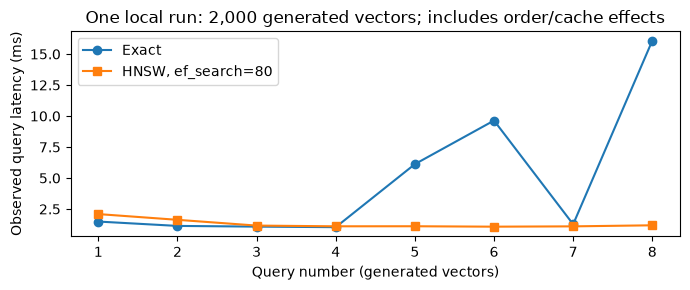

In [5]:
from raglab.benchmark import prepare,measure,recall
import matplotlib.pyplot as plt
with db.connect() as conn:
    vectors=prepare(conn,n=2000,seed=7)
    queries=vectors[::250].copy()
    exact,exact_ms=measure(conn,queries,exact=True)
    conn.execute("CREATE INDEX ann_hnsw ON ann_lab USING hnsw(embedding vector_cosine_ops) WITH (m=8,ef_construction=64)")
    conn.execute("SET LOCAL hnsw.ef_search=80")
    approximate,ann_ms=measure(conn,queries)
    conn.execute("SET LOCAL enable_seqscan=off")
    plan=conn.execute("EXPLAIN (FORMAT JSON) SELECT id FROM ann_lab ORDER BY embedding <=> %s LIMIT 10",(queries[0],)).fetchone()
    print(json.dumps(plan,default=str)[:1800])
    print({"neighbor_recall_at_10":recall(exact,approximate),"queries":len(queries)})
plt.figure(figsize=(7,3))
plt.plot(range(1,9),exact_ms,"o-",label="Exact")
plt.plot(range(1,9),ann_ms,"s-",label="HNSW, ef_search=80")
plt.xlabel("Query number (generated vectors)");plt.ylabel("Observed query latency (ms)")
plt.title("One local run: 2,000 generated vectors; includes order/cache effects")
plt.legend();plt.tight_layout();plt.show()

### 4. TODO: compare both approximate indexes (40 points)
Implement `build_index(conn,kind)` for the existing temporary `ann_lab` table. Drop only the two lab index names, then create either HNSW (`m=8`, `ef_construction=64`) or IVFFlat (`lists=16`), with `vector_cosine_ops`. Reject other kinds before issuing SQL. Use fixed SQL strings. Do not leave both indexes present when comparing plans. IVFFlat builds after data insertion in this experiment.

In [6]:
def build_index(conn,kind):
    raise NotImplementedError("Create the chosen pgvector index")

In [7]:
if RUN_EXERCISES:
    with db.connect() as conn:
        vectors=prepare(conn,n=2000,seed=7)
        queries=vectors[::250]
        reference,_=measure(conn,queries,exact=True,cohort=0)
        for kind in ("hnsw","ivfflat"):
            build_index(conn,kind)
            conn.execute("SET LOCAL hnsw.ef_search=80")
            conn.execute("SET LOCAL ivfflat.probes=8")
            result,times=measure(conn,queries,cohort=0)
            score=recall(reference,result)
            assert 0<=score<=1
            print({"index":kind,"filtered_recall":score,"returned_counts":[len(r) for r in result]})
        try: build_index(conn,"hnsw; DROP TABLE x")
        except ValueError: pass
        else: raise AssertionError("unsafe index kind accepted")

## Checks and submission
Run at least two `ef_search` settings and two `ivfflat.probes` settings, repeat query ordering, and retain EXPLAIN plans. Report build time, index size using `pg_relation_size`, returned result count, neighbor recall@10, and latency distribution. Include an empty tenant, wrong embedding dimension, zero vector, NaN, and a restrictive filter.

Do not report an ANN speedup from one query. In the filtered experiment, fewer than k returned rows is a result to investigate. Read pgvector's filtering/iterative-scan guidance before proposing a fix. Keep approximate-neighbor recall separate from human relevance labels.

Rubric: search SQL 30, index DDL 40, experiments 20, interpretation 10. Lab 14 measures relevance on the actual policy corpus.

## Next Steps
For production, evaluate a tenant/index strategy with realistic data and concurrency. This tiny fixture does not establish capacity or a universally best index.

References checked 2026-10-07: [pgvector exact search, HNSW, IVFFlat, filtering and EXPLAIN](https://github.com/pgvector/pgvector), [PostgreSQL EXPLAIN](https://www.postgresql.org/docs/current/using-explain.html).